### 2_3 - Train    on both semantic and geometrique of query (  Umap )

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ds/cleaned_amazon_queries_dataset_en_50k_geo_semant_umap.csv')
cols = ['query' , 'Unnamed: 0'] 


x = data.drop(columns=cols)

In [2]:
x.head(3)

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count,emb_0,emb_1,emb_2,...,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14
0,-0.651438,-0.917934,-0.419985,-0.365241,1.004975,-0.913646,-0.201665,9.971348,6.191277,5.308603,...,4.896664,4.411188,4.665093,3.931290,3.995985,4.573812,2.660951,5.258607,6.649301,3.715641
1,-0.250755,-0.346518,-0.419985,-0.365241,0.160833,-0.345260,-0.201665,10.164223,6.551484,5.090791,...,4.146534,4.472170,4.676391,4.897981,3.552489,4.875464,0.991174,5.689204,3.477242,4.564904
2,-0.851779,-0.346518,-0.419985,-0.365241,-1.286269,-0.345260,-0.201665,10.004557,6.528174,5.287583,...,3.348886,4.228767,5.053605,4.204326,4.645471,3.953676,1.800899,5.820741,4.941647,2.841812


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled_array, columns=x.columns, index=x.index)

x = X_scaled
x.head(5)

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count,emb_0,emb_1,emb_2,...,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14
0,-0.651438,-0.917934,-0.419985,-0.365241,1.004975,-0.913646,-0.201665,-0.232015,-2.219193,0.349320,...,0.323407,-0.069238,-0.851785,-0.646595,-1.177674,-0.237862,0.987626,-0.066171,2.037496,-0.550347
1,-0.250755,-0.346518,-0.419985,-0.365241,0.160833,-0.345260,-0.201665,0.849199,0.196780,-0.391605,...,-0.519912,-0.032120,-0.835782,0.604728,-1.910657,0.145467,-1.310196,0.878418,-2.433543,0.158854
2,-0.851779,-0.346518,-0.419985,-0.365241,-1.286269,-0.345260,-0.201665,-0.045853,0.040438,0.277816,...,-1.416652,-0.180272,-0.301464,-0.293167,-0.104246,-1.025910,-0.195913,1.166967,-0.369454,-1.280063
3,-1.252462,-0.917934,-0.419985,-0.365241,-1.165677,-0.913646,-0.201665,-0.394056,0.365964,0.009844,...,0.441185,-0.537451,0.244747,-0.433883,-0.199213,-0.797077,-0.702991,1.293480,-0.033094,0.928108
4,0.550610,0.224898,-0.419985,-0.365241,0.462312,0.223126,2.753563,0.280027,-1.689833,0.048543,...,0.871550,-0.473299,1.174776,0.273820,1.368246,-1.124081,1.786553,-0.504661,1.960294,1.413711


#### Kmeans

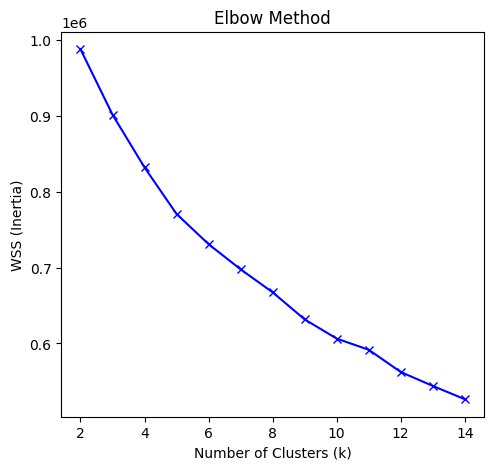

In [ ]:
#elbow method to find best k

wss = []
silhouette_avg = []
k_range = range(2, 15) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    #  WSS for Elbow
    wss.append(kmeans.inertia_)
    

# Plotting the results for your paper
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Elbow Method')


plt.show()


#no clear point

In [53]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)

for k in range(50, 200, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)


# best based on silhouette_score is k = 2

2 0.12100281002588559
3 0.11501984841293587
4 0.13183395400766468
5 0.1542129433002263
6 0.15897127834817074
7 0.15452856182074962
8 0.1615084927485432
9 0.15986868116578612
50 0.18574192144411167
65 0.1808881556618428
80 0.17607931113048159
95 0.1851506731434562
110 0.18285718806841458
125 0.1892137920215117
140 0.19273241215334397
155 0.18454338655589345
170 0.19756619432299216
185 0.18970090779100823


In [4]:
#Kmeans Model 

kmeans_final = KMeans(n_clusters=65, random_state=41, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
5     2005
59    1747
35    1563
41    1456
10    1433
      ... 
60      93
52      57
31      45
9       34
64      20
Name: count, Length: 65, dtype: int64


In [55]:
for i in range(65):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(10).values)


--- Examples of Cluster 0 ---
<StringArray>
[                  'delta force book',                     'rogue magazine',
                       'address book', 'kindle instructions for paperwhite',
            'cancel hbo subscription',            'hollywood rides diecast',
                     'gap creek book',                       'abcd puzzles',
     'the testaments margaret atwood',    'best selling books for toddlers']
Length: 10, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[      '+foot cream without alcohol',                   'lebel cosmetics',
              'shampoo living proof',                         'handsoaps',
                'japanese sunscreen',                'dude wipes for men',
    'organic exfoliating face wipes', 'clinical strength hyaluronic acid',
               'siamond clean brush',              'concealer maybelline']
Length: 10, dtype: str

--- Examples of Cluster 2 ---
<StringArray>
['smartfood delight popcorn',      'adobe incense burner',


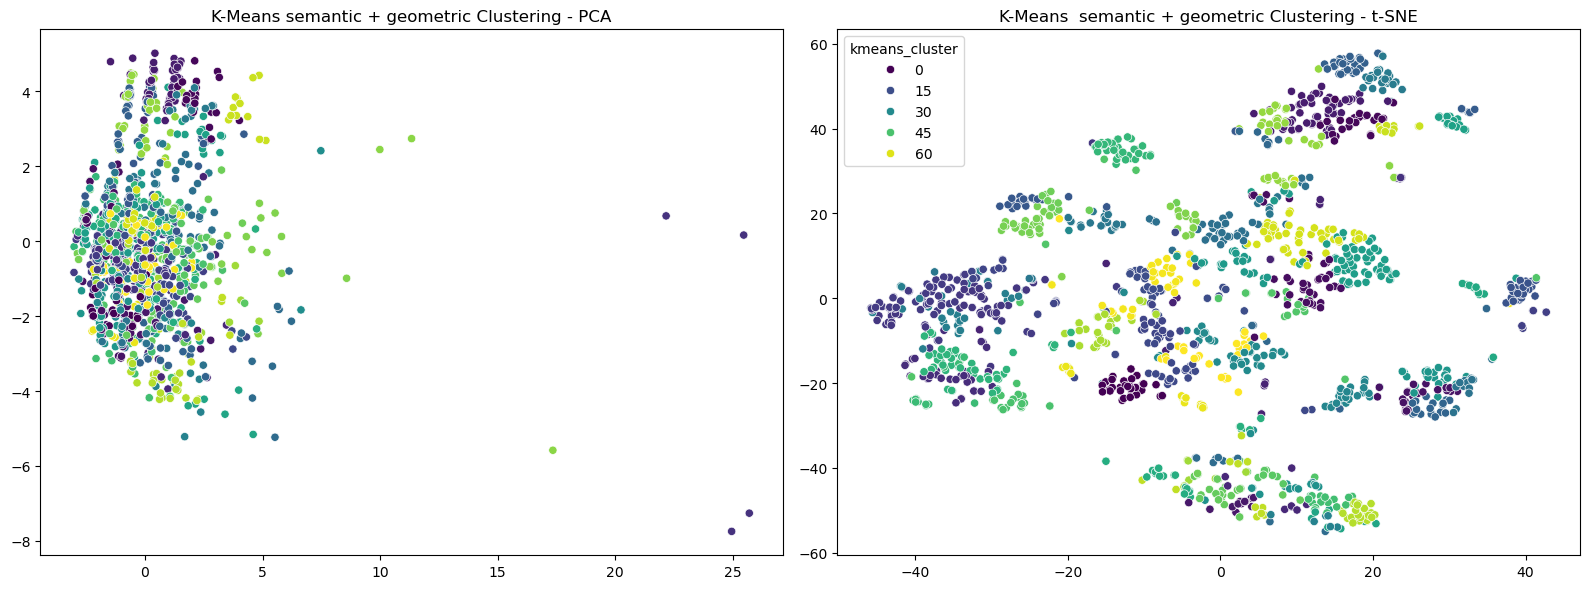

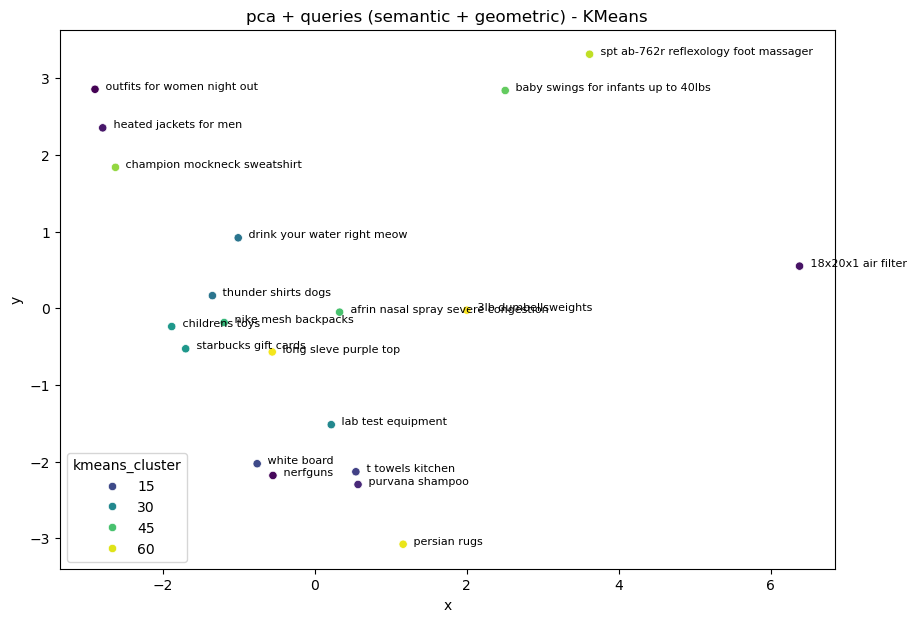

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['kmeans_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("K-Means semantic + geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("K-Means  semantic + geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=30)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='kmeans_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['kmeans_cluster'].unique():
    cluster_points = sample[sample['kmeans_cluster'] == cluster].head(8)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (semantic + geometric) - KMeans")
plt.show()

#### GMM

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# Sample for speed
sample_idx = np.random.choice(len(x), size=min(5000, len(x)), replace=False)
x_sample = x.iloc[sample_idx] if hasattr(x, 'iloc') else x[sample_idx]

bic_scores = []
aic_scores = []
K_range = range(5, 101, 5)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=3
    )
    gmm.fit(x_sample)
    bic_scores.append(gmm.bic(x_sample))
    aic_scores.append(gmm.aic(x_sample))
    print(f"K={k}  BIC={gmm.bic(x_sample):.2f}  AIC={gmm.aic(x_sample):.2f}")

In [9]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

#gmm model
gmm = GaussianMixture(n_components=65, random_state=42)


data['gmm_cluster'] = gmm.fit_predict(x)


In [58]:
for i in range(65):
    print(f"\n--- GMM Cluster {i} ---")
    print(data[data['gmm_cluster'] == i]['query'].head(8).values)


--- GMM Cluster 0 ---
<StringArray>
[                         'hockey gifts for boys',
                               'percy's progress',
                          'day without a mexican',
 'the money book for the young, fabulous & broke',
                            'high school english',
           'anatomy and physiology coloring book',
                                'g.thomas couser',
         'learning without tears writing journal']
Length: 8, dtype: str

--- GMM Cluster 1 ---
<StringArray>
[                     'black zipties',                 'metal for adulting',
                       'bb-gun rifle',                              'bongs',
 'zipline for backyard without trees',                 'techincs turntable',
 'eva dry wireless mini dehumidifier',                         'aqua magic']
Length: 8, dtype: str

--- GMM Cluster 2 ---
<StringArray>
[            'scooby doo live action', 'light of the world amy jill levine',
            'xbox one x console only',            'h

In [10]:
# probability 
probs = gmm.predict_proba(x)

data['gmm_confidence'] = probs.max(axis=1)

print(data[['query', 'gmm_cluster', 'gmm_confidence']].head(10))

                                  query  gmm_cluster  gmm_confidence
0                       workout weights           59        1.000000
1                   nintendo gift cards           42        1.000000
2                         urban skin rx           13        1.000000
3                             bird seed           57        0.999908
4           +foot cream without alcohol           29        1.000000
5  brother tn730 high yield black toner           22        1.000000
6                             60 lashes           63        1.000000
7                          cpap filters           41        1.000000
8         long cord lavalier microphone           33        1.000000
9               tumblers bulk wholesale           54        1.000000


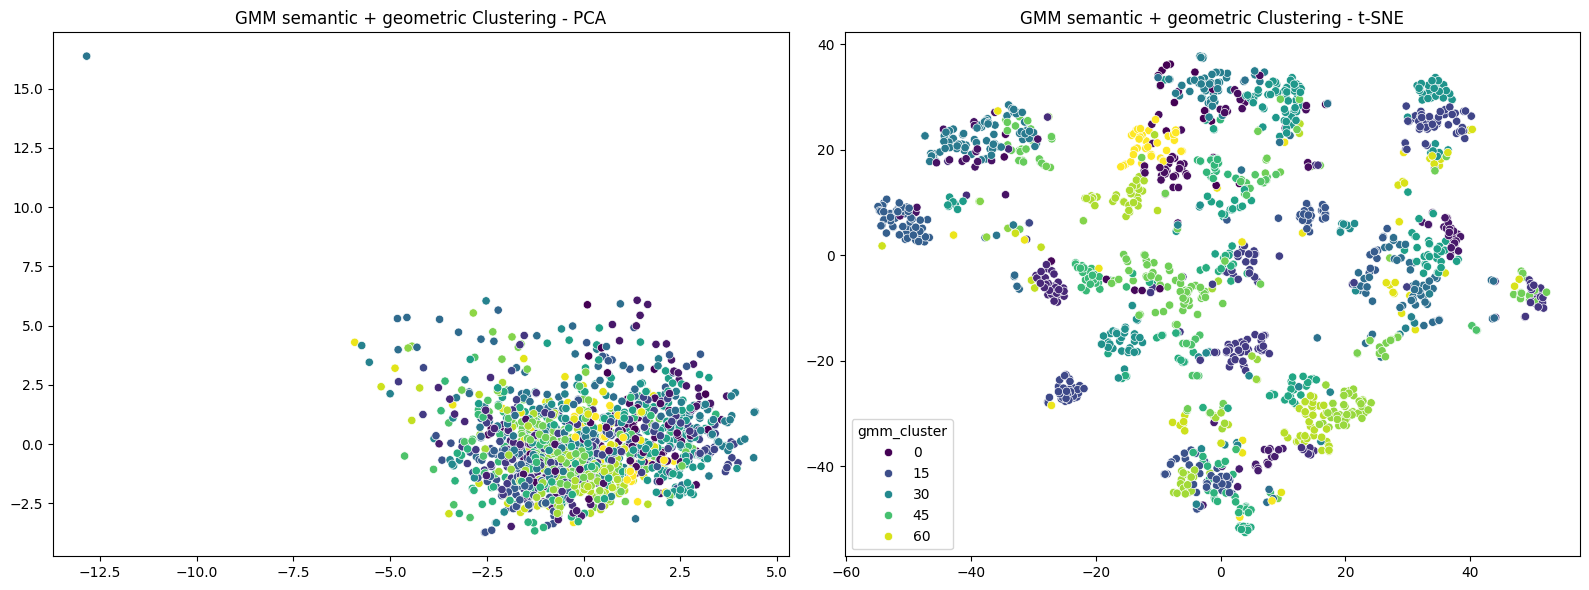

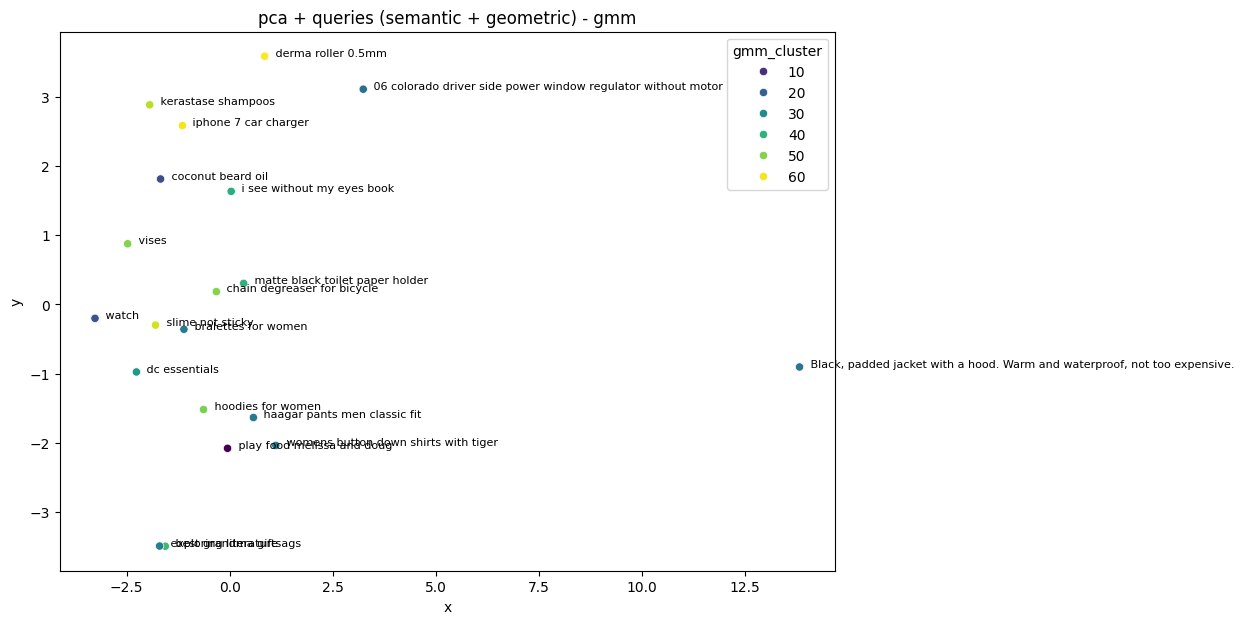

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['gmm_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=41)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("GMM semantic + geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("GMM semantic + geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=381)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='gmm_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['gmm_cluster'].unique():
    cluster_points = sample[sample['gmm_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (semantic + geometric) - gmm")
plt.show()

#### DBscan

Suggested eps: 2.2603


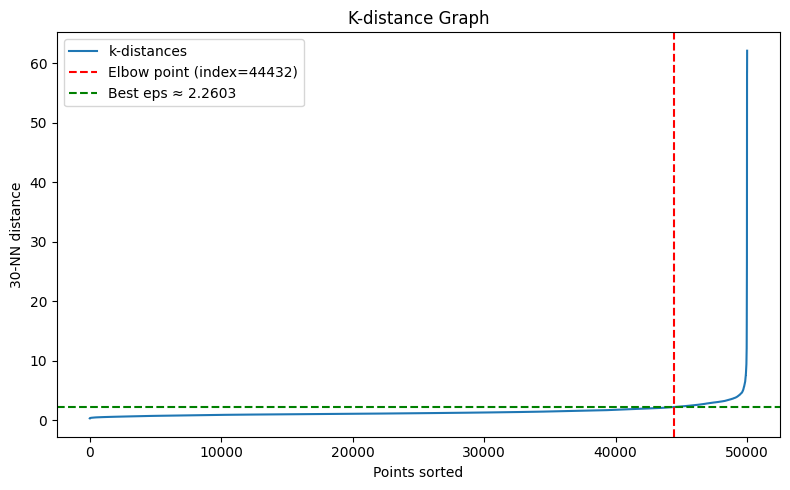

In [61]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from kneed import KneeLocator

k = 30
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

distances = np.sort(distances[:, k-1])

# Detect elbow/knee point
kneedle = KneeLocator(
    range(len(distances)), 
    distances, 
    curve="convex", 
    direction="increasing",
    interp_method="polynomial" 
)

best_eps = distances[kneedle.knee]
print(f"Suggested eps: {best_eps:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(distances, label="k-distances")
plt.axvline(x=kneedle.knee, color="red", linestyle="--", label=f"Elbow point (index={kneedle.knee})")
plt.axhline(y=best_eps, color="green", linestyle="--", label=f"Best eps ≈ {best_eps:.4f}")
plt.title("K-distance Graph")
plt.xlabel("Points sorted")
plt.ylabel(f"{k}-NN distance")
plt.legend()
plt.tight_layout()
plt.show()
#

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2.26,min_samples=50
)

labels = dbscan.fit_predict(x)

data['db_cluster'] = labels


print(data['db_cluster'].value_counts())

for c in sorted(data['db_cluster'].unique()):
    print("\n Cluster", c)
    print(data[data['db_cluster'] == c]['query'].head(5).tolist())

db_cluster
 0    40871
-1     4293
 1     4053
 2      149
 4      123
 5      103
 9       97
 6       89
 3       78
 7       78
 8       66
Name: count, dtype: int64

 Cluster -1
['+foot cream without alcohol', 'brother tn730 high yield black toner', '60 lashes', 'compost bags 3 gallon', '06 suzuki 600 side fairing not painted']

 Cluster 0
['workout weights', 'nintendo gift cards', 'urban skin rx', 'bird seed', 'cpap filters']

 Cluster 1
['iphone used 6', 'rear rack duke 390', '1 inch block heels', 'otterbox iphone 7 case black', '10 oz nuk learner sippy cup without handles']

 Cluster 2
['10 lb resistance band without handles', 'iphone watch series 3 bands for women', 'garmin forerunner 735xt band replacement', 'apple 5 watch bands', 'garmin forerunner 30']

 Cluster 3
['cute airpods case', 'airpods pro case cover zelda', 'cute airpods case', 'case airpods pro', 'airpods pro']

 Cluster 4
["men's armour fleece pants", 'mens t-shirts', "men's armour fleece pants", "women's short t

C:\Users\hp\AppData\Local\Temp\ipykernel_14204\3108372453.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')


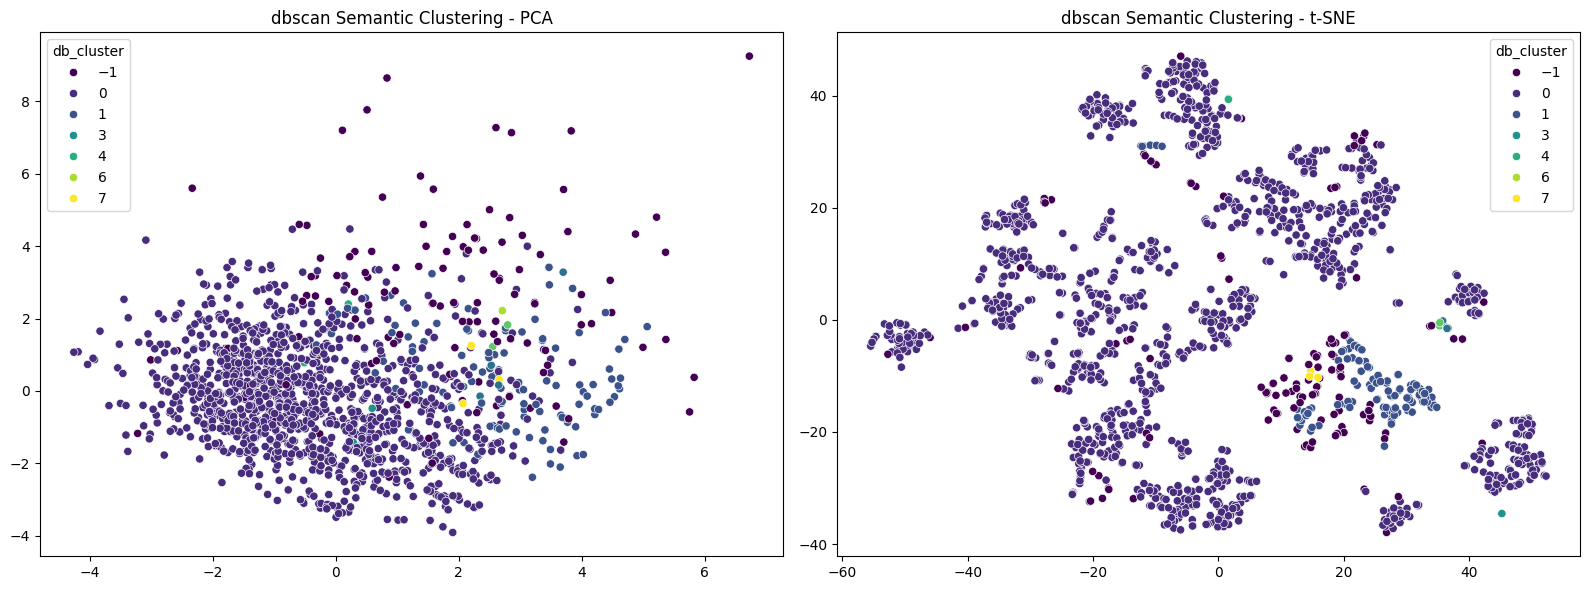

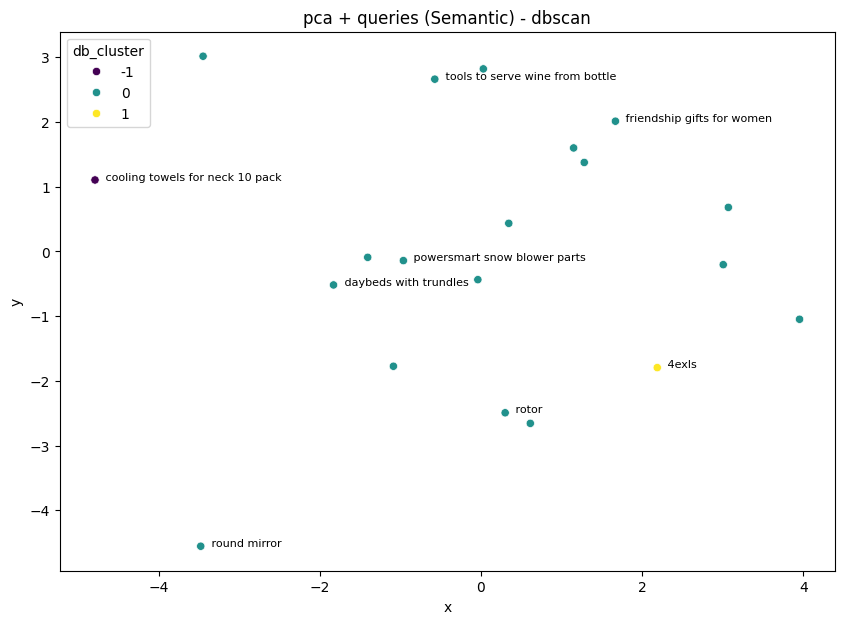

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['db_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=412)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    
)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
axes[0].set_title("dbscan Semantic Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("dbscan Semantic Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=308)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='db_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['db_cluster'].unique():
    cluster_points = sample[sample['db_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (Semantic) - dbscan")
plt.show()

### hdbscan

In [ ]:
import optuna
import hdbscan
import numpy as np

def objective(trial):
    # Define the ranges for the "best" parameters
    mcs = trial.suggest_int('min_cluster_size', 40, 300)
    ms = trial.suggest_int('min_samples', 1, 50)
    ep = trial.suggest_float('epsilon', 0.0, 0.3)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        cluster_selection_epsilon=ep,
        cluster_selection_method='leaf',
        core_dist_n_jobs=-1
    )
    
    labels = clusterer.fit_predict(x) # Use your UMAP-reduced data
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels)
    
    # Penalty if there are too few clusters or too much noise
    if n_clusters < 40 or noise_pct > 0.30:
        return -1.0
    
    # We use a sample for speed to calculate the DBCV score
    try:
        idx = np.random.choice(len(x), 5000, replace=False)
        score = hdbscan.validity.validity_index(x.values[idx].astype(np.float64), labels[idx])
    except:
        score = -1
        
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # 30 trials is usually enough to find the peak

print("Best Parameters:", study.best_params)

[I 2026-05-11 20:30:19,817] A new study created in memory with name: no-name-6d6a41ec-2442-42b8-bd3c-1f00a8d24d82
[I 2026-05-11 20:31:04,383] Trial 0 finished with value: -1.0 and parameters: {'min_cluster_size': 54, 'min_samples': 48, 'epsilon': 0.25177908175539737}. Best is trial 0 with value: -1.0.
[I 2026-05-11 20:31:44,968] Trial 1 finished with value: -1.0 and parameters: {'min_cluster_size': 253, 'min_samples': 45, 'epsilon': 0.0307915253183886}. Best is trial 0 with value: -1.0.
[I 2026-05-11 20:33:20,509] Trial 2 finished with value: -1.0 and parameters: {'min_cluster_size': 55, 'min_samples': 5, 'epsilon': 0.11023221101425043}. Best is trial 0 with value: -1.0.
[I 2026-05-11 20:34:09,579] Trial 3 finished with value: -1.0 and parameters: {'min_cluster_size': 233, 'min_samples': 33, 'epsilon': 0.22416829192575113}. Best is trial 0 with value: -1.0.
[I 2026-05-11 20:34:47,871] Trial 4 finished with value: -1.0 and parameters: {'min_cluster_size': 96, 'min_samples': 45, 'epsilon

In [4]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=104,    
    min_samples=1,     
    cluster_selection_epsilon=0.23,  
)

labels_hdb = clusterer.fit_predict(x)

data['hdbscan_cluster'] = labels_hdb

print(data['hdbscan_cluster'].value_counts())

for c in sorted(data['hdbscan_cluster'].unique()):
    print(f"\n HDBscan Cluster {c} ---")
    print(data[data['hdbscan_cluster'] == c]['query'].head(5).tolist())

hdbscan_cluster
-1     17351
 1      5943
 0      1127
 91     1084
 3       847
       ...  
 8       108
 96      108
 90      107
 59      106
 73      104
Name: count, Length: 109, dtype: int64

 HDBscan Cluster -1 ---
['workout weights', 'cpap filters', 'tumblers bulk wholesale', 'hyundai accent steering wheel sign sticker', 'bronze toilet paper holder']

 HDBscan Cluster 0 ---
['hose reel 1/4', 'pma ep-2', '.8 beading wire plastic not stretchy', '2 1/2 exhaust elbow', 'pentel 0.3 mm mechanical pencil']

 HDBscan Cluster 1 ---
['brother tn730 high yield black toner', '60 lashes', 'iphone used 6', 'compost bags 3 gallon', '06 suzuki 600 side fairing not painted']

 HDBscan Cluster 2 ---
['#do not disturb, jeidah bila', 'The jacket I am planning on buying is a hoodie with high visibility reflective strips on it, for safety.', 'the money book for the young, fabulous & broke', '*cancer free thyroid not included*shirt', 'd.a. young kindle books']

 HDBscan Cluster 3 ---
['+foot cream w

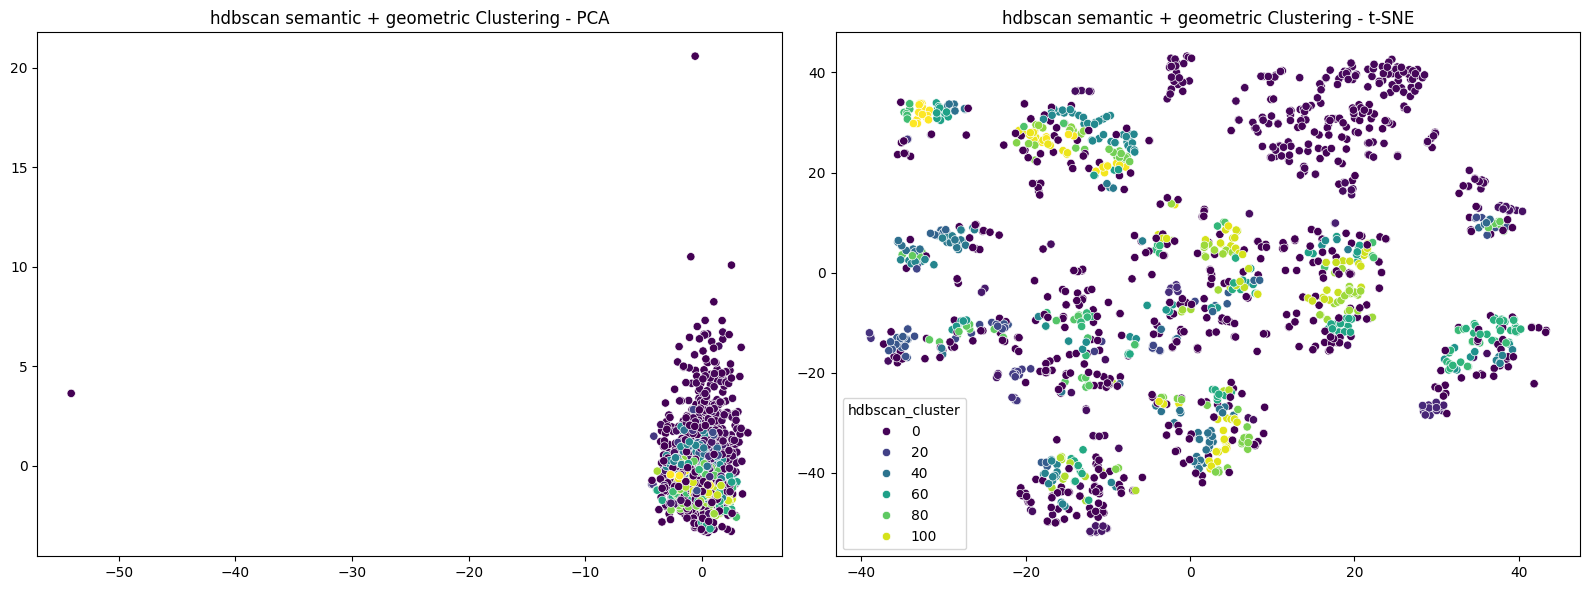

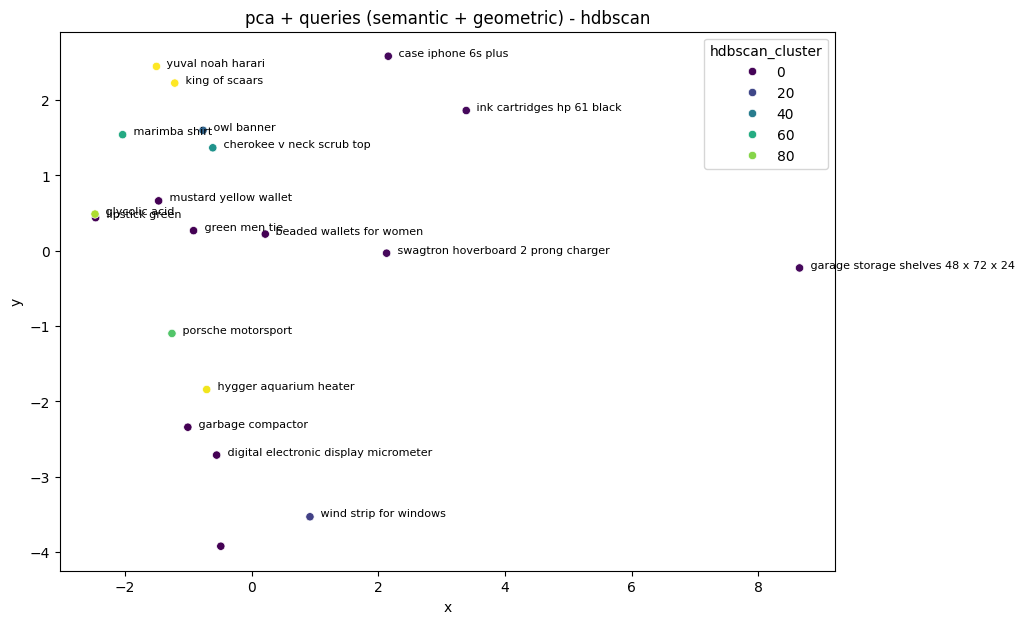

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['hdbscan_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=1)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("hdbscan semantic + geometric Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("hdbscan semantic + geometric Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=81)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='hdbscan_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['hdbscan_cluster'].unique():
    cluster_points = sample[sample['hdbscan_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (semantic + geometric) - hdbscan")
plt.show()

### evaluating

In [6]:
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score
import numpy as np

In [12]:
#to calculate silhout scor fast
sample_idx = np.random.choice(len(x), size=15000, replace=False)
X_sample = x.iloc[sample_idx].values

models = {
    "kmeans": data['kmeans_cluster'],
    "gmm": data['gmm_cluster'],
    "dbscan": data['db_cluster'],
    "hdbscan": data['hdbscan_cluster']
}

results = []

for name, column in models.items():
    
    labels = column.values
    X_values = x.values
    
    # noise remove dbscan and hdb
    mask = labels != -1
    
    # less clusters
    if len(set(labels[mask])) < 2:
        continue

    #  silhouette on 5k sam
    labels_sample = labels[sample_idx]
    mask_sample = labels_sample != -1
    
    if len(set(labels_sample[mask_sample])) > 1:
        sil = silhouette_score(
            X_sample[mask_sample],
            labels_sample[mask_sample]
        )
    else:
        sil = np.nan

    
    ch = calinski_harabasz_score(X_values[mask], labels[mask])
    db = davies_bouldin_score(X_values[mask], labels[mask])

    results.append({
        "model": name,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": len(set(labels[mask]))
    })

results_df = pd.DataFrame(results)
print(results_df)

     model  silhouette  calinski_harabasz  davies_bouldin  n_clusters
0   kmeans    0.179897        2345.782266        1.537063          65
1      gmm    0.125235        1640.375345        2.199576          65
2   dbscan   -0.022636         567.174460        1.459866          10
3  hdbscan    0.022289         643.395531        2.088427         108
